# 11 — Supervised Normal-vs-Abnormal mini-MIAS Baseline

This notebook provides a **supervised transfer-learning baseline** for the same normal-vs-abnormal task used in Notebook 10.

### Research question
How well can a supervised CNN distinguish **genuinely normal** mini-MIAS mammograms from mammograms containing an abnormality?

### Label mapping
- `NORM` → `0 = normal`
- `CALC`, `CIRC`, `SPIC`, `MISC`, `ARCH`, `ASYM` → `1 = abnormal`

### Why this is separate from Notebook 10
Notebook 10 is a **one-class** experiment: only normal training images define the normal distribution.  
Notebook 11 is a **supervised discriminative** experiment: both normal and abnormal training labels are used.

A higher supervised AUC therefore does **not** mean the one-class experiment was implemented incorrectly; the learning settings are different.

### Methodological safeguards
- same mini-MIAS cohort as Notebook 10;
- same patient-level train/validation/locked-test split whenever Notebook 10's saved split file is available;
- left/right mammograms from one patient stay in the same split;
- class weights are estimated from the training split only;
- train-only augmentation;
- model selection uses validation ROC-AUC;
- operating threshold is selected on validation data only;
- the locked test set is evaluated after model/threshold selection;
- patient-level bootstrap confidence intervals are reported.


## 1. Setup and Paths

Use a **T4 GPU** or better in Colab. The dataset should already exist at:

```text
Data/Normal_Abnormal/all-mias/
```

The notebook preferentially reuses Notebook 10's exact split assignments:

```text
Results/10_Normal_vs_Abnormal_Anomaly_Detection/
    exact_patient_level_split_assignments.csv
```

If that file is unavailable, it regenerates the same deterministic patient-level split using seed 42.


In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os
import re
import json
import random
import hashlib
import platform
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd

from PIL import Image
from scipy import ndimage

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)

import matplotlib.pyplot as plt
from tqdm.auto import tqdm


# ============================================================
# Paths
# ============================================================

PROJECT_DIR = "/content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification"

DATASET_DIR = os.path.join(
    PROJECT_DIR,
    "Data",
    "Normal_Abnormal",
)

MIAS_DIR = os.path.join(
    DATASET_DIR,
    "all-mias",
)

MANIFEST_PATH = os.path.join(
    DATASET_DIR,
    "normal_abnormal_manifest.csv",
)

NB10_RESULT_DIR = os.path.join(
    PROJECT_DIR,
    "Results",
    "10_Normal_vs_Abnormal_Anomaly_Detection",
)

NB10_SPLIT_PATH = os.path.join(
    NB10_RESULT_DIR,
    "exact_patient_level_split_assignments.csv",
)

NB10_PREDICTIONS_PATH = os.path.join(
    NB10_RESULT_DIR,
    "locked_test_predictions.csv",
)

OUTPUT_DIR = os.path.join(
    PROJECT_DIR,
    "Results",
    "11_Supervised_Normal_vs_Abnormal_miniMIAS",
)

MODEL_DIR = os.path.join(
    PROJECT_DIR,
    "Models",
    "Supervised_miniMIAS",
)

FIGURE_DIR = os.path.join(
    PROJECT_DIR,
    "Figures",
    "Classification",
)

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)


# ============================================================
# Configuration
# ============================================================

SEED = 42
IMG_SIZE = 512
BATCH_SIZE = 8
NUM_WORKERS = 0

TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.15
TEST_FRACTION = 0.15

HEAD_EPOCHS = 5
FINETUNE_EPOCHS = 25
EARLY_STOPPING_PATIENCE = 7

HEAD_LR = 1e-3
BACKBONE_LR = 1e-5
FINETUNE_HEAD_LR = 1e-4
WEIGHT_DECAY = 1e-4

BOOTSTRAP_N = 1000

CACHE_DIR = f"/content/mini_mias_supervised_cache_{IMG_SIZE}"

BEST_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "resnet50_supervised_normal_abnormal_best.pth",
)


# ============================================================
# Reproducibility
# ============================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

PIN_MEMORY = bool(torch.cuda.is_available())


print("Project:", PROJECT_DIR)
print("mini-MIAS:", MIAS_DIR)
print("Output:", OUTPUT_DIR)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU not detected. The notebook will still run, but training will be slower.")

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)

if not os.path.isdir(MIAS_DIR):
    raise FileNotFoundError(
        f"mini-MIAS directory not found:\n{MIAS_DIR}"
    )


Mounted at /content/drive
Project: /content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification
mini-MIAS: /content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Data/Normal_Abnormal/all-mias
Output: /content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Results/11_Supervised_Normal_vs_Abnormal_miniMIAS
Device: cuda
GPU: Tesla T4
Python: 3.12.13
PyTorch: 2.11.0+cu128


## 2. Load the mini-MIAS Manifest

Notebook 10 already generated `normal_abnormal_manifest.csv`. This cell validates it rather than inventing new labels.

The expected dataset contains **322 images** grouped into **161 patient pairs**.


In [2]:
if not os.path.isfile(MANIFEST_PATH):
    raise FileNotFoundError(
        "normal_abnormal_manifest.csv was not found.\n"
        "Run Notebook 10's manifest-building section first."
    )

manifest = pd.read_csv(MANIFEST_PATH)

required = {
    "image_path",
    "patient_id",
    "label",
    "source",
    "sample_id",
}

missing = required - set(manifest.columns)

if missing:
    raise KeyError(
        "Manifest missing required columns: "
        + ", ".join(sorted(missing))
    )

df = manifest.copy()

df["label"] = df["label"].astype(int)
df["patient_id"] = df["patient_id"].astype(str)
df["sample_id"] = df["sample_id"].astype(str)
df["source"] = df["source"].astype(str)

if len(df) != 322:
    raise ValueError(
        f"Expected 322 mini-MIAS images, found {len(df)}."
    )

if df["patient_id"].nunique() != 161:
    raise ValueError(
        f"Expected 161 patient groups, found {df['patient_id'].nunique()}."
    )

if set(df["label"].unique()) != {0, 1}:
    raise ValueError("Expected binary labels {0,1}.")

if not df["sample_id"].is_unique:
    raise ValueError("sample_id values must be unique.")

missing_images = [
    p for p in df["image_path"]
    if not os.path.isfile(str(p))
]

if missing_images:
    raise FileNotFoundError(
        f"{len(missing_images)} image paths are missing. "
        "The first missing path is:\n"
        + str(missing_images[0])
    )

print("Manifest validated.")
print("Images:", len(df))
print("Patients:", df["patient_id"].nunique())

display(
    df.groupby("label")
      .agg(
          images=("sample_id", "count"),
          patients=("patient_id", "nunique"),
      )
      .rename(index={0: "normal", 1: "abnormal"})
)

if "abnormality" in df.columns:
    print("\nAbnormality distribution:")
    display(
        df["abnormality"]
        .value_counts()
        .rename("images")
        .to_frame()
    )


Manifest validated.
Images: 322
Patients: 161


,images,patients
label,,
normal,207,154
abnormal,115,108



Abnormality distribution:


,images
abnormality,
NORM,207
CALC,25
CIRC,23
SPIC,19
ARCH,19
ASYM,15
MISC,14


## 3. Reuse Notebook 10's Patient-Level Split

To make the supervised and one-class experiments directly comparable, this notebook uses the **same train/validation/locked-test patients** as Notebook 10 whenever possible.


In [3]:
def generate_patient_split(dataframe):
    patient_table = (
        dataframe.groupby("patient_id", as_index=False)
        .agg(
            patient_label=("label", "max"),
            images=("sample_id", "count"),
        )
    )

    train_pat, temp_pat = train_test_split(
        patient_table,
        test_size=(1.0 - TRAIN_FRACTION),
        stratify=patient_table["patient_label"],
        random_state=SEED,
    )

    test_share_of_temp = (
        TEST_FRACTION
        / (VAL_FRACTION + TEST_FRACTION)
    )

    val_pat, test_pat = train_test_split(
        temp_pat,
        test_size=test_share_of_temp,
        stratify=temp_pat["patient_label"],
        random_state=SEED,
    )

    split_map = {}

    split_map.update({
        pid: "train"
        for pid in train_pat["patient_id"]
    })

    split_map.update({
        pid: "validation"
        for pid in val_pat["patient_id"]
    })

    split_map.update({
        pid: "locked_test"
        for pid in test_pat["patient_id"]
    })

    return dataframe["patient_id"].map(split_map)


if os.path.isfile(NB10_SPLIT_PATH):
    print("Reusing Notebook 10 exact split:")
    print(NB10_SPLIT_PATH)

    split_df = pd.read_csv(NB10_SPLIT_PATH)

    needed = {"sample_id", "patient_id", "label", "split"}

    if not needed.issubset(split_df.columns):
        raise KeyError(
            "Notebook 10 split file does not contain "
            "sample_id, patient_id, label and split."
        )

    split_df["sample_id"] = split_df["sample_id"].astype(str)

    split_lookup = (
        split_df[
            ["sample_id", "split"]
        ]
        .drop_duplicates("sample_id")
    )

    df = df.drop(
        columns=["split"],
        errors="ignore",
    ).merge(
        split_lookup,
        on="sample_id",
        how="left",
        validate="one_to_one",
    )

    if df["split"].isna().any():
        raise ValueError(
            "Some mini-MIAS images were not found in Notebook 10's split file."
        )

else:
    print(
        "Notebook 10 split file not found. "
        "Regenerating the deterministic seed-42 patient split."
    )

    df["split"] = generate_patient_split(df)


train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df = df[df["split"] == "validation"].reset_index(drop=True)
test_df = df[df["split"] == "locked_test"].reset_index(drop=True)


# ------------------------------------------------------------
# Leakage checks
# ------------------------------------------------------------

for a, b, name in [
    (train_df, val_df, "train vs validation"),
    (train_df, test_df, "train vs locked_test"),
    (val_df, test_df, "validation vs locked_test"),
]:
    overlap = set(a["patient_id"]) & set(b["patient_id"])

    if overlap:
        raise RuntimeError(
            f"Patient leakage detected in {name}: "
            f"{len(overlap)} patients."
        )


for name, part in [
    ("train", train_df),
    ("validation", val_df),
    ("locked_test", test_df),
]:
    if set(part["label"].unique()) != {0, 1}:
        raise ValueError(
            f"{name} does not contain both classes."
        )


split_summary = pd.DataFrame([
    {
        "split": name,
        "images": len(part),
        "patients": part["patient_id"].nunique(),
        "normal_images": int((part["label"] == 0).sum()),
        "abnormal_images": int((part["label"] == 1).sum()),
        "abnormal_rate": float(part["label"].mean()),
    }
    for name, part in [
        ("train", train_df),
        ("validation", val_df),
        ("locked_test", test_df),
    ]
])

display(split_summary.round(4))

split_summary.to_csv(
    os.path.join(OUTPUT_DIR, "split_summary.csv"),
    index=False,
)

df[
    [
        "sample_id",
        "patient_id",
        "label",
        "source",
        "image_path",
        "split",
    ]
].to_csv(
    os.path.join(
        OUTPUT_DIR,
        "exact_patient_level_split_assignments.csv",
    ),
    index=False,
)

print("Patient-level split confirmed.")


Reusing Notebook 10 exact split:
/content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Results/10_Normal_vs_Abnormal_Anomaly_Detection/exact_patient_level_split_assignments.csv


,split,images,patients,normal_images,abnormal_images,abnormal_rate
0,train,224,112,144,80,0.3571
1,validation,48,24,32,16,0.3333
2,locked_test,50,25,31,19,0.3800


Patient-level split confirmed.


## 4. Breast-Crop Preprocessing

The same broad breast-crop logic as Notebook 10 is used:

1. estimate foreground using Otsu thresholding,
2. retain the largest connected breast region,
3. crop with a small margin,
4. pad to a square without stretching,
5. resize to 512×512.

The processed images are cached in the Colab runtime for training speed.


preprocess train:   0%|          | 0/224 [00:00<?, ?it/s]

preprocess train: cached 224 new images (total split size=224)


preprocess validation:   0%|          | 0/48 [00:00<?, ?it/s]

preprocess validation: cached 48 new images (total split size=48)


preprocess locked_test:   0%|          | 0/50 [00:00<?, ?it/s]

preprocess locked_test: cached 50 new images (total split size=50)


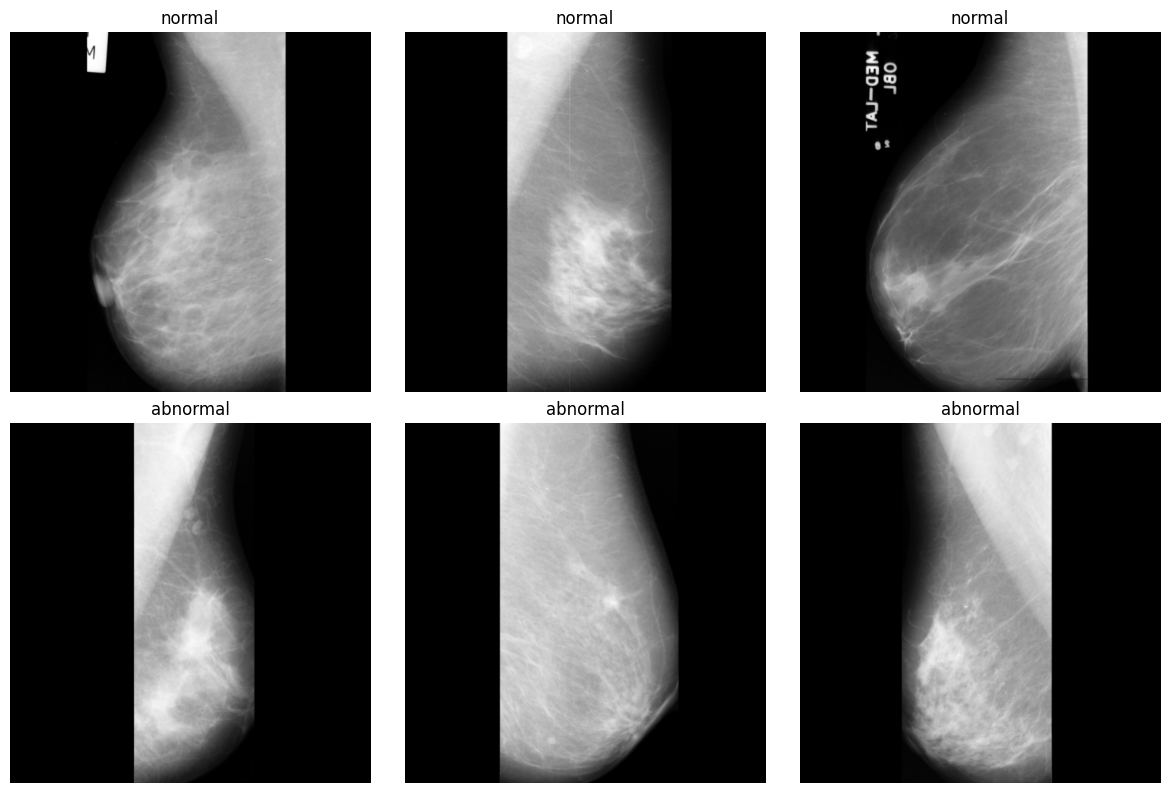

In [4]:
try:
    RESAMPLE_BILINEAR = Image.Resampling.BILINEAR
except AttributeError:
    RESAMPLE_BILINEAR = Image.BILINEAR


def otsu_threshold(gray):
    hist = np.bincount(
        gray.ravel(),
        minlength=256,
    ).astype(np.float64)

    prob = hist / max(gray.size, 1)
    omega = np.cumsum(prob)
    mu = np.cumsum(prob * np.arange(256))
    mu_t = mu[-1]

    sigma = (
        (mu_t * omega - mu) ** 2
        / np.maximum(
            omega * (1 - omega),
            1e-12,
        )
    )

    sigma[(omega <= 0) | (omega >= 1)] = 0

    return int(np.argmax(sigma))


def breast_bbox(gray_u8, pad_frac=0.02):
    h, w = gray_u8.shape

    mask = gray_u8 > max(
        otsu_threshold(gray_u8),
        5,
    )

    mask = ndimage.binary_opening(
        mask,
        structure=np.ones((3, 3)),
    )

    mask = ndimage.binary_closing(
        mask,
        structure=np.ones((7, 7)),
    )

    labels, n_labels = ndimage.label(mask)

    if n_labels == 0:
        return (0, 0, w, h)

    counts = np.bincount(labels.ravel())
    counts[0] = 0

    ys, xs = np.where(
        labels == counts.argmax()
    )

    if len(xs) == 0:
        return (0, 0, w, h)

    pad = int(
        round(pad_frac * max(h, w))
    )

    return (
        max(int(xs.min()) - pad, 0),
        max(int(ys.min()) - pad, 0),
        min(int(xs.max()) + 1 + pad, w),
        min(int(ys.max()) + 1 + pad, h),
    )


def preprocess_mammogram(path):
    gray = np.array(
        Image.open(path).convert("L"),
        dtype=np.uint8,
    )

    left, top, right, bottom = breast_bbox(gray)

    crop = Image.fromarray(gray).crop(
        (left, top, right, bottom)
    )

    cw, ch = crop.size
    side = max(cw, ch)

    canvas = Image.new(
        "L",
        (side, side),
        0,
    )

    canvas.paste(
        crop,
        (
            (side - cw) // 2,
            (side - ch) // 2,
        ),
    )

    return canvas.resize(
        (IMG_SIZE, IMG_SIZE),
        RESAMPLE_BILINEAR,
    )


def cache_path(sample_id):
    return os.path.join(
        CACHE_DIR,
        f"{sample_id}.png",
    )


def build_cache(dataframe, description):
    os.makedirs(CACHE_DIR, exist_ok=True)

    rebuilt = 0

    for row in tqdm(
        dataframe.itertuples(),
        total=len(dataframe),
        desc=description,
    ):
        out_path = cache_path(row.sample_id)

        if os.path.isfile(out_path):
            continue

        processed = preprocess_mammogram(
            row.image_path
        )

        processed.save(out_path)
        rebuilt += 1

    print(
        f"{description}: cached {rebuilt} new images "
        f"(total split size={len(dataframe)})"
    )


build_cache(train_df, "preprocess train")
build_cache(val_df, "preprocess validation")
build_cache(test_df, "preprocess locked_test")


# Visual sanity check
example_rows = pd.concat(
    [
        train_df[train_df["label"] == 0].sample(
            min(3, (train_df["label"] == 0).sum()),
            random_state=SEED,
        ),
        train_df[train_df["label"] == 1].sample(
            min(3, (train_df["label"] == 1).sum()),
            random_state=SEED + 1,
        ),
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 8),
)

for ax, (_, row) in zip(
    axes.ravel(),
    example_rows.iterrows(),
):
    img = Image.open(
        cache_path(row.sample_id)
    )

    ax.imshow(img, cmap="gray")
    ax.set_title(
        "normal" if row.label == 0 else "abnormal"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()


## 5. Dataset and Train-Only Augmentation

Because mini-MIAS is small, the training split receives **moderate augmentation only**:

- horizontal flip,
- small rotation,
- small translation,
- mild brightness/contrast variation.

Validation and test images receive no stochastic augmentation.


In [5]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(
        degrees=7,
        translate=(0.03, 0.03),
        scale=(0.97, 1.03),
    ),
    transforms.ColorJitter(
        brightness=0.08,
        contrast=0.08,
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD,
    ),
])


eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD,
    ),
])


class MammogramDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(
            cache_path(row.sample_id)
        ).convert("L")

        image = self.transform(image)

        return {
            "image": image,
            "label": torch.tensor(
                float(row.label),
                dtype=torch.float32,
            ),
            "sample_id": str(row.sample_id),
            "patient_id": str(row.patient_id),
        }


train_loader = DataLoader(
    MammogramDataset(train_df, train_transform),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

val_loader = DataLoader(
    MammogramDataset(val_df, eval_transform),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_loader = DataLoader(
    MammogramDataset(test_df, eval_transform),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)


normal_train = int(
    (train_df["label"] == 0).sum()
)

abnormal_train = int(
    (train_df["label"] == 1).sum()
)

POS_WEIGHT = (
    normal_train / max(abnormal_train, 1)
)

print("Train normal images:", normal_train)
print("Train abnormal images:", abnormal_train)
print("BCE positive-class weight:", round(POS_WEIGHT, 4))


Train normal images: 144
Train abnormal images: 80
BCE positive-class weight: 1.8


## 6. ResNet-50 Supervised Transfer-Learning Baseline

A standard ImageNet-pretrained ResNet-50 is used.

Training has two conventional stages:

1. **Head warm-up:** only the new binary classifier is trained.
2. **Partial fine-tuning:** `layer4` and the classifier are trained at low learning rates.

This remains a baseline transfer-learning setup; it does not use ROI masks, metadata, ensembles, or test-set tuning.


In [6]:
def build_model():
    try:
        weights = models.ResNet50_Weights.IMAGENET1K_V2
        model = models.resnet50(weights=weights)
    except Exception as exc:
        raise RuntimeError(
            "Could not load ImageNet-pretrained ResNet-50 weights. "
            "Check Colab internet access and rerun."
        ) from exc

    in_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Dropout(p=0.30),
        nn.Linear(in_features, 1),
    )

    return model.to(device)


model = build_model()


def freeze_all_backbone(model):
    for parameter in model.parameters():
        parameter.requires_grad = False

    for parameter in model.fc.parameters():
        parameter.requires_grad = True


def unfreeze_layer4_and_head(model):
    for parameter in model.parameters():
        parameter.requires_grad = False

    for parameter in model.layer4.parameters():
        parameter.requires_grad = True

    for parameter in model.fc.parameters():
        parameter.requires_grad = True


freeze_all_backbone(model)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(
        [POS_WEIGHT],
        dtype=torch.float32,
        device=device,
    )
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print("Total parameters:", f"{total_params:,}")
print("Head-stage trainable parameters:", f"{trainable_params:,}")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 174MB/s]


Total parameters: 23,510,081
Head-stage trainable parameters: 2,049


## 7. Training Utilities

The best checkpoint is selected by **validation ROC-AUC only**.

The locked test set is not used during training, early stopping, learning-rate decisions, or threshold selection.


In [7]:
def run_loader(model, loader, optimizer=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    losses = []
    labels = []
    probabilities = []
    sample_ids = []
    patient_ids = []

    context = (
        torch.enable_grad()
        if is_train
        else torch.no_grad()
    )

    with context:
        for batch in loader:
            images = batch["image"].to(
                device,
                non_blocking=True,
            )

            y = batch["label"].to(
                device,
                non_blocking=True,
            )

            if is_train:
                optimizer.zero_grad(
                    set_to_none=True
                )

            logits = model(images).squeeze(1)

            loss = criterion(
                logits,
                y,
            )

            if is_train:
                loss.backward()
                optimizer.step()

            prob = torch.sigmoid(
                logits
            )

            losses.append(
                loss.detach().cpu().item()
            )

            labels.extend(
                y.detach().cpu().numpy().tolist()
            )

            probabilities.extend(
                prob.detach().cpu().numpy().tolist()
            )

            sample_ids.extend(
                list(batch["sample_id"])
            )

            patient_ids.extend(
                list(batch["patient_id"])
            )

    labels = np.asarray(
        labels,
        dtype=int,
    )

    probabilities = np.asarray(
        probabilities,
        dtype=float,
    )

    auc = roc_auc_score(
        labels,
        probabilities,
    )

    pr_auc = average_precision_score(
        labels,
        probabilities,
    )

    return {
        "loss": float(np.mean(losses)),
        "roc_auc": float(auc),
        "pr_auc": float(pr_auc),
        "y_true": labels,
        "probability": probabilities,
        "sample_id": np.asarray(sample_ids),
        "patient_id": np.asarray(patient_ids),
    }


history = []
best_val_auc = -np.inf
best_epoch_label = None
patience_counter = 0


def maybe_save_best(
    model,
    epoch_label,
    val_result,
):
    global best_val_auc
    global best_epoch_label
    global patience_counter

    improved = (
        val_result["roc_auc"]
        > best_val_auc + 1e-6
    )

    if improved:
        best_val_auc = val_result["roc_auc"]
        best_epoch_label = epoch_label
        patience_counter = 0

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "best_val_auc": best_val_auc,
                "epoch_label": epoch_label,
                "img_size": IMG_SIZE,
                "seed": SEED,
            },
            BEST_MODEL_PATH,
        )
    else:
        patience_counter += 1

    return improved


## 8. Phase 1 — Classifier Head Warm-Up


In [8]:
optimizer = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        model.parameters(),
    ),
    lr=HEAD_LR,
    weight_decay=WEIGHT_DECAY,
)


for epoch in range(1, HEAD_EPOCHS + 1):
    train_result = run_loader(
        model,
        train_loader,
        optimizer=optimizer,
    )

    val_result = run_loader(
        model,
        val_loader,
        optimizer=None,
    )

    epoch_label = f"head_{epoch:02d}"

    improved = maybe_save_best(
        model,
        epoch_label,
        val_result,
    )

    history.append({
        "phase": "head",
        "epoch": epoch,
        "train_loss": train_result["loss"],
        "train_auc": train_result["roc_auc"],
        "val_loss": val_result["loss"],
        "val_auc": val_result["roc_auc"],
        "val_pr_auc": val_result["pr_auc"],
        "best_so_far": bool(improved),
    })

    print(
        f"[Head {epoch:02d}/{HEAD_EPOCHS}] "
        f"train loss={train_result['loss']:.4f} "
        f"train AUC={train_result['roc_auc']:.4f} | "
        f"val loss={val_result['loss']:.4f} "
        f"val AUC={val_result['roc_auc']:.4f} "
        f"{'★ best' if improved else ''}"
    )


print(
    "Best validation AUC after head stage:",
    round(best_val_auc, 4),
)


[Head 01/5] train loss=0.9134 train AUC=0.4891 | val loss=0.8765 val AUC=0.5566 ★ best
[Head 02/5] train loss=0.8899 train AUC=0.5216 | val loss=0.8752 val AUC=0.5332 
[Head 03/5] train loss=0.8993 train AUC=0.5103 | val loss=0.8912 val AUC=0.5176 
[Head 04/5] train loss=0.8926 train AUC=0.5670 | val loss=0.8872 val AUC=0.4082 
[Head 05/5] train loss=0.8980 train AUC=0.4918 | val loss=0.8924 val AUC=0.4199 
Best validation AUC after head stage: 0.5566


## 9. Phase 2 — Partial Fine-Tuning

Only ResNet-50 `layer4` plus the binary classifier are unfrozen. Early stopping is based solely on validation ROC-AUC.


In [9]:
unfreeze_layer4_and_head(model)

optimizer = torch.optim.AdamW(
    [
        {
            "params": model.layer4.parameters(),
            "lr": BACKBONE_LR,
        },
        {
            "params": model.fc.parameters(),
            "lr": FINETUNE_HEAD_LR,
        },
    ],
    weight_decay=WEIGHT_DECAY,
)

patience_counter = 0


for epoch in range(1, FINETUNE_EPOCHS + 1):
    train_result = run_loader(
        model,
        train_loader,
        optimizer=optimizer,
    )

    val_result = run_loader(
        model,
        val_loader,
        optimizer=None,
    )

    epoch_label = f"finetune_{epoch:02d}"

    improved = maybe_save_best(
        model,
        epoch_label,
        val_result,
    )

    history.append({
        "phase": "finetune",
        "epoch": epoch,
        "train_loss": train_result["loss"],
        "train_auc": train_result["roc_auc"],
        "val_loss": val_result["loss"],
        "val_auc": val_result["roc_auc"],
        "val_pr_auc": val_result["pr_auc"],
        "best_so_far": bool(improved),
    })

    print(
        f"[Fine {epoch:02d}/{FINETUNE_EPOCHS}] "
        f"train loss={train_result['loss']:.4f} "
        f"train AUC={train_result['roc_auc']:.4f} | "
        f"val loss={val_result['loss']:.4f} "
        f"val AUC={val_result['roc_auc']:.4f} "
        f"{'★ best' if improved else ''}"
    )

    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(
            "Early stopping: no validation AUC improvement "
            f"for {EARLY_STOPPING_PATIENCE} epochs."
        )
        break


history_df = pd.DataFrame(history)

history_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "training_history.csv",
    ),
    index=False,
)

print("\nBest validation AUC:", round(best_val_auc, 4))
print("Best checkpoint:", best_epoch_label)
print("Saved:", BEST_MODEL_PATH)


[Fine 01/25] train loss=0.8817 train AUC=0.5905 | val loss=0.8958 val AUC=0.4062 
[Fine 02/25] train loss=0.8742 train AUC=0.6124 | val loss=0.8990 val AUC=0.4121 
[Fine 03/25] train loss=0.8802 train AUC=0.5878 | val loss=0.8985 val AUC=0.4199 
[Fine 04/25] train loss=0.8747 train AUC=0.6091 | val loss=0.9001 val AUC=0.4277 
[Fine 05/25] train loss=0.8779 train AUC=0.5856 | val loss=0.9008 val AUC=0.4141 
[Fine 06/25] train loss=0.8841 train AUC=0.5706 | val loss=0.8978 val AUC=0.4375 
[Fine 07/25] train loss=0.8760 train AUC=0.5920 | val loss=0.9083 val AUC=0.4180 
Early stopping: no validation AUC improvement for 7 epochs.

Best validation AUC: 0.5566
Best checkpoint: head_01
Saved: /content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Models/Supervised_miniMIAS/resnet50_supervised_normal_abnormal_best.pth


## 10. Reload Best Validation Checkpoint

This ensures the locked-test evaluation uses the checkpoint chosen **before looking at test performance**.


In [10]:
checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device,
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print(
    "Loaded best checkpoint:",
    checkpoint["epoch_label"],
)

print(
    "Checkpoint validation AUC:",
    round(
        float(checkpoint["best_val_auc"]),
        4,
    ),
)


Loaded best checkpoint: head_01
Checkpoint validation AUC: 0.5566


## 11. Validation-Only Threshold Selection

The binary operating threshold is chosen using **Youden's J** on the validation set. The selected threshold is then frozen.


In [11]:
def classification_metrics(
    y_true,
    probability,
    threshold,
):
    y_true = np.asarray(
        y_true,
        dtype=int,
    )

    probability = np.asarray(
        probability,
        dtype=float,
    )

    y_pred = (
        probability >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    ).ravel()

    sensitivity = (
        tp / (tp + fn)
        if (tp + fn)
        else np.nan
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp)
        else np.nan
    )

    return {
        "roc_auc": roc_auc_score(
            y_true,
            probability,
        ),
        "pr_auc": average_precision_score(
            y_true,
            probability,
        ),
        "threshold": float(threshold),
        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred,
        ),
        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "sensitivity": sensitivity,
        "specificity": specificity,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def select_threshold_youden(
    y_true,
    probability,
):
    fpr, tpr, thresholds = roc_curve(
        y_true,
        probability,
    )

    valid = np.isfinite(thresholds)

    fpr = fpr[valid]
    tpr = tpr[valid]
    thresholds = thresholds[valid]

    youden = tpr - fpr

    best_index = int(
        np.argmax(youden)
    )

    return float(
        thresholds[best_index]
    )


val_result = run_loader(
    model,
    val_loader,
    optimizer=None,
)

VALIDATION_THRESHOLD = select_threshold_youden(
    val_result["y_true"],
    val_result["probability"],
)

validation_metrics = classification_metrics(
    val_result["y_true"],
    val_result["probability"],
    VALIDATION_THRESHOLD,
)

print(
    "Frozen validation-selected threshold:",
    round(VALIDATION_THRESHOLD, 6),
)

display(
    pd.DataFrame(
        [validation_metrics]
    ).round(4)
)


pd.DataFrame({
    "sample_id": val_result["sample_id"],
    "patient_id": val_result["patient_id"],
    "y_true": val_result["y_true"],
    "probability": val_result["probability"],
    "threshold": VALIDATION_THRESHOLD,
    "y_pred": (
        val_result["probability"]
        >= VALIDATION_THRESHOLD
    ).astype(int),
}).to_csv(
    os.path.join(
        OUTPUT_DIR,
        "validation_predictions.csv",
    ),
    index=False,
)


Frozen validation-selected threshold: 0.495179


,roc_auc,pr_auc,threshold,accuracy,balanced_accuracy,f1,precision,sensitivity,specificity,tn,fp,fn,tp
0,0.5566,0.3845,0.4952,0.5208,0.5938,0.5306,0.3939,0.8125,0.375,12,20,3,13


## 12. Locked-Test Evaluation

The locked test set is evaluated once using the checkpoint and threshold selected from validation data.


In [12]:
test_result = run_loader(
    model,
    test_loader,
    optimizer=None,
)

test_metrics = classification_metrics(
    test_result["y_true"],
    test_result["probability"],
    VALIDATION_THRESHOLD,
)

test_metrics_df = pd.DataFrame(
    [test_metrics]
)

display(
    test_metrics_df.round(4)
)


test_predictions = pd.DataFrame({
    "sample_id": test_result["sample_id"],
    "patient_id": test_result["patient_id"],
    "y_true": test_result["y_true"],
    "probability": test_result["probability"],
    "threshold": VALIDATION_THRESHOLD,
    "y_pred": (
        test_result["probability"]
        >= VALIDATION_THRESHOLD
    ).astype(int),
})


test_metrics_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "locked_test_metrics.csv",
    ),
    index=False,
)

test_predictions.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "locked_test_predictions.csv",
    ),
    index=False,
)


,roc_auc,pr_auc,threshold,accuracy,balanced_accuracy,f1,precision,sensitivity,specificity,tn,fp,fn,tp
0,0.5874,0.5266,0.4952,0.56,0.5535,0.4762,0.4348,0.5263,0.5806,18,13,9,10


## 13. Patient-Level Bootstrap Confidence Intervals

Patients, rather than individual mammograms, are resampled because each patient may contribute two views.


In [13]:
def patient_bootstrap_metrics(
    predictions,
    n_boot=BOOTSTRAP_N,
    seed=SEED,
):
    rng = np.random.default_rng(seed)

    by_patient = {
        pid: group
        for pid, group
        in predictions.groupby("patient_id")
    }

    patient_ids = np.array(
        list(by_patient.keys())
    )

    rows = []

    for _ in range(n_boot):
        sampled_patients = rng.choice(
            patient_ids,
            size=len(patient_ids),
            replace=True,
        )

        boot = pd.concat(
            [
                by_patient[pid]
                for pid in sampled_patients
            ],
            ignore_index=True,
        )

        if boot["y_true"].nunique() < 2:
            continue

        metrics = classification_metrics(
            boot["y_true"],
            boot["probability"],
            float(boot["threshold"].iloc[0]),
        )

        rows.append({
            key: metrics[key]
            for key in [
                "roc_auc",
                "pr_auc",
                "sensitivity",
                "specificity",
                "balanced_accuracy",
                "f1",
            ]
        })

    return pd.DataFrame(rows)


boot = patient_bootstrap_metrics(
    test_predictions
)

ci_rows = []

for metric in [
    "roc_auc",
    "pr_auc",
    "sensitivity",
    "specificity",
    "balanced_accuracy",
    "f1",
]:
    ci_rows.append({
        "metric": metric,
        "observed": test_metrics[metric],
        "ci_low": boot[metric].quantile(0.025),
        "ci_high": boot[metric].quantile(0.975),
        "n_boot": len(boot),
    })


ci_df = pd.DataFrame(
    ci_rows
)

display(
    ci_df.round(4)
)

ci_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "locked_test_patient_bootstrap_ci.csv",
    ),
    index=False,
)


,metric,observed,ci_low,ci_high,n_boot
0,roc_auc,0.5874,0.4173,0.7317,1000
1,pr_auc,0.5266,0.3398,0.7077,1000
2,sensitivity,0.5263,0.2778,0.7647,1000
3,specificity,0.5806,0.4000,0.7576,1000
4,balanced_accuracy,0.5535,0.4317,0.6712,1000
5,f1,0.4762,0.2778,0.6251,1000


## 14. Paired Comparison with Notebook 10 One-Class Primary Method

If Notebook 10's locked-test predictions are available, the supervised ResNet-50 is compared with **Isolation Forest**, which was the primary one-class method selected by validation AUC in the completed Notebook 10 run.

The paired bootstrap uses the same locked-test patients and reports:

`Supervised ResNet50 AUC − Isolation Forest AUC`

This comparison is methodologically useful because the task and split are the same, but the learning paradigms differ: supervised learning uses both labels during training, whereas one-class learning uses normal training examples only.


In [14]:
comparison_df = None

if os.path.isfile(NB10_PREDICTIONS_PATH):
    nb10 = pd.read_csv(
        NB10_PREDICTIONS_PATH
    )

    required_nb10 = {
        "method",
        "sample_id",
        "patient_id",
        "y_true",
        "anomaly_score",
    }

    if required_nb10.issubset(nb10.columns):
        nb10_if = (
            nb10[
                nb10["method"]
                == "IsolationForest"
            ][
                [
                    "sample_id",
                    "patient_id",
                    "y_true",
                    "anomaly_score",
                ]
            ]
            .rename(
                columns={
                    "anomaly_score":
                    "oneclass_score"
                }
            )
        )

        supervised = (
            test_predictions[
                [
                    "sample_id",
                    "patient_id",
                    "y_true",
                    "probability",
                ]
            ]
            .rename(
                columns={
                    "probability":
                    "supervised_score"
                }
            )
        )

        merged = supervised.merge(
            nb10_if,
            on="sample_id",
            suffixes=("_sup", "_oc"),
            validate="one_to_one",
        )

        if len(merged) == len(test_predictions):
            if not np.array_equal(
                merged["y_true_sup"].to_numpy(),
                merged["y_true_oc"].to_numpy(),
            ):
                raise RuntimeError(
                    "Label mismatch between Notebook 10 "
                    "and Notebook 11 predictions."
                )

            observed_supervised_auc = roc_auc_score(
                merged["y_true_sup"],
                merged["supervised_score"],
            )

            observed_oneclass_auc = roc_auc_score(
                merged["y_true_sup"],
                merged["oneclass_score"],
            )

            observed_delta = (
                observed_supervised_auc
                - observed_oneclass_auc
            )

            by_patient = {
                pid: group
                for pid, group
                in merged.groupby(
                    "patient_id_sup"
                )
            }

            patient_ids = np.array(
                list(by_patient.keys())
            )

            rng = np.random.default_rng(
                SEED
            )

            deltas = []

            for _ in range(BOOTSTRAP_N):
                sampled = rng.choice(
                    patient_ids,
                    size=len(patient_ids),
                    replace=True,
                )

                boot_pair = pd.concat(
                    [
                        by_patient[pid]
                        for pid in sampled
                    ],
                    ignore_index=True,
                )

                if (
                    boot_pair["y_true_sup"]
                    .nunique()
                    < 2
                ):
                    continue

                delta = (
                    roc_auc_score(
                        boot_pair["y_true_sup"],
                        boot_pair[
                            "supervised_score"
                        ],
                    )
                    - roc_auc_score(
                        boot_pair["y_true_sup"],
                        boot_pair[
                            "oneclass_score"
                        ],
                    )
                )

                deltas.append(delta)

            comparison_df = pd.DataFrame([{
                "comparison":
                "Supervised ResNet50 - Notebook10 IsolationForest",
                "supervised_auc":
                observed_supervised_auc,
                "oneclass_auc":
                observed_oneclass_auc,
                "delta_auc":
                observed_delta,
                "ci_low":
                np.quantile(
                    deltas,
                    0.025,
                ),
                "ci_high":
                np.quantile(
                    deltas,
                    0.975,
                ),
                "n_boot":
                len(deltas),
            }])

            display(
                comparison_df.round(4)
            )

            comparison_df.to_csv(
                os.path.join(
                    OUTPUT_DIR,
                    "paired_auc_vs_notebook10.csv",
                ),
                index=False,
            )

        else:
            print(
                "Notebook 10 predictions found, but sample IDs "
                "do not exactly match the current locked-test set. "
                "Paired comparison skipped."
            )

    else:
        print(
            "Notebook 10 prediction file does not contain "
            "the expected columns. Paired comparison skipped."
        )

else:
    print(
        "Notebook 10 locked-test prediction file not found. "
        "Paired comparison skipped."
    )


,comparison,supervised_auc,oneclass_auc,delta_auc,ci_low,ci_high,n_boot
0,Supervised ResNet50 - Notebook10 IsolationForest,0.5874,0.5688,0.0187,-0.216,0.2135,1000


## 15. Figures

The notebook saves:
- training/validation ROC-AUC history,
- locked-test ROC and PR curves,
- locked-test confusion matrix.


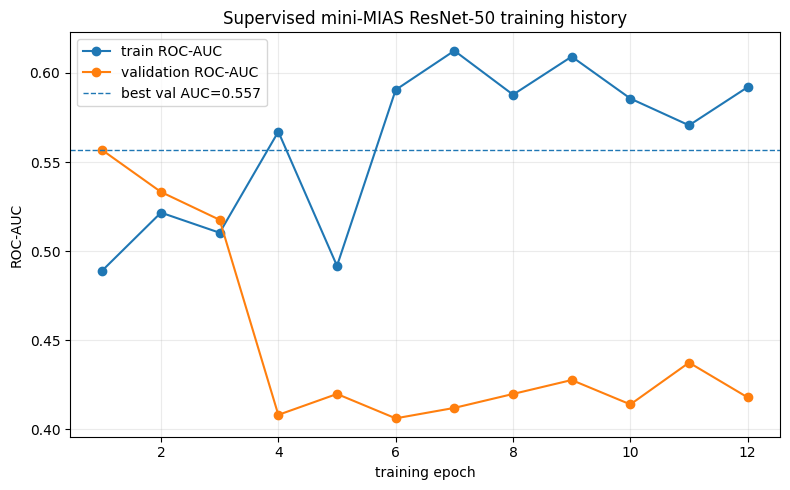

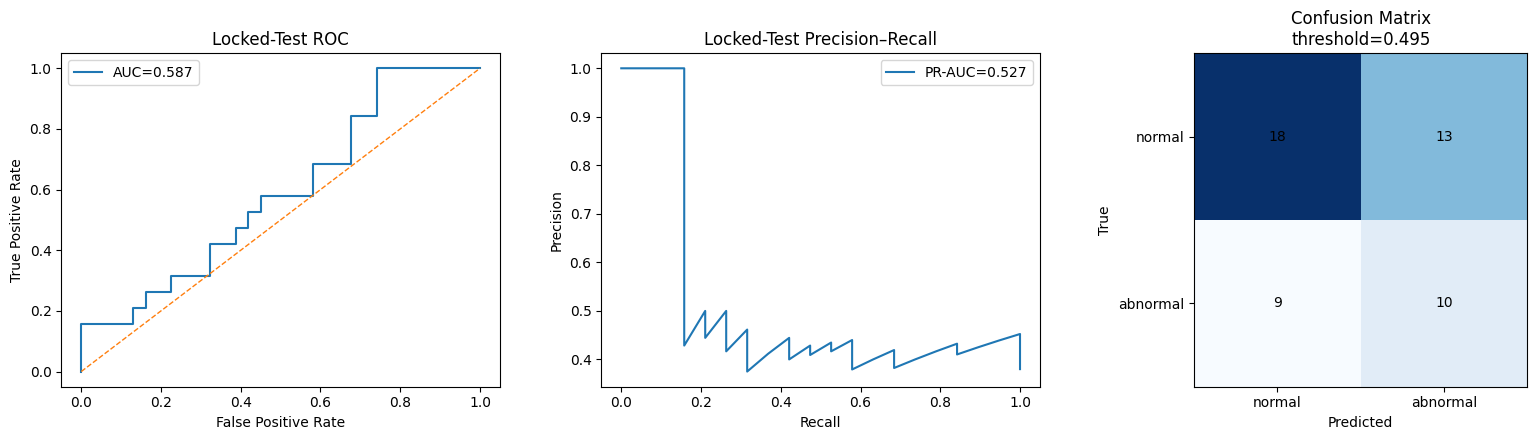

Saved: /content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Results/11_Supervised_Normal_vs_Abnormal_miniMIAS/training_auc_history.png
Saved: /content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Results/11_Supervised_Normal_vs_Abnormal_miniMIAS/supervised_locked_test_figures.png
Saved report figure: /content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Figures/Classification/11_supervised_miniMIAS_locked_test.png


In [15]:
# ------------------------------------------------------------
# Training history
# ------------------------------------------------------------

fig = plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(history_df) + 1),
    history_df["train_auc"],
    marker="o",
    label="train ROC-AUC",
)

plt.plot(
    np.arange(1, len(history_df) + 1),
    history_df["val_auc"],
    marker="o",
    label="validation ROC-AUC",
)

plt.axhline(
    best_val_auc,
    linestyle="--",
    linewidth=1,
    label=f"best val AUC={best_val_auc:.3f}",
)

plt.xlabel("training epoch")
plt.ylabel("ROC-AUC")
plt.title(
    "Supervised mini-MIAS ResNet-50 training history"
)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

history_fig = os.path.join(
    OUTPUT_DIR,
    "training_auc_history.png",
)

plt.savefig(
    history_fig,
    dpi=200,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------
# Locked-test ROC / PR / confusion matrix
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4.5),
)

y_true = test_predictions["y_true"].to_numpy()
score = test_predictions["probability"].to_numpy()
y_pred = test_predictions["y_pred"].to_numpy()

fpr, tpr, _ = roc_curve(
    y_true,
    score,
)

precision, recall, _ = precision_recall_curve(
    y_true,
    score,
)

axes[0].plot(
    fpr,
    tpr,
    label=f"AUC={test_metrics['roc_auc']:.3f}",
)

axes[0].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
)

axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("Locked-Test ROC")
axes[0].legend()


axes[1].plot(
    recall,
    precision,
    label=f"PR-AUC={test_metrics['pr_auc']:.3f}",
)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Locked-Test Precision–Recall")
axes[1].legend()


cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1],
)

axes[2].imshow(
    cm,
    cmap="Blues",
)

axes[2].set_xticks(
    [0, 1],
    ["normal", "abnormal"],
)

axes[2].set_yticks(
    [0, 1],
    ["normal", "abnormal"],
)

axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("True")
axes[2].set_title(
    f"Confusion Matrix\nthreshold={VALIDATION_THRESHOLD:.3f}"
)

for i in range(2):
    for j in range(2):
        axes[2].text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
        )


plt.tight_layout()

test_fig = os.path.join(
    OUTPUT_DIR,
    "supervised_locked_test_figures.png",
)

report_fig = os.path.join(
    FIGURE_DIR,
    "11_supervised_miniMIAS_locked_test.png",
)

plt.savefig(
    test_fig,
    dpi=200,
    bbox_inches="tight",
)

plt.savefig(
    report_fig,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Saved:", history_fig)
print("Saved:", test_fig)
print("Saved report figure:", report_fig)


## 16. Final Dissertation Summary

Suggested interpretation:

> A supervised ResNet-50 transfer-learning baseline was trained on the same patient-level mini-MIAS normal-vs-abnormal split used for the one-class experiment. Unlike one-class modelling, the supervised model used both normal and abnormal training labels. Model selection was based on validation ROC-AUC, the classification threshold was selected on validation data, and final performance was assessed once on the locked test set with patient-level bootstrap confidence intervals.

### Reporting rule
If the supervised model substantially outperforms Notebook 10, describe this as evidence that **discriminative supervision is more effective for this small mini-MIAS task than normal-only one-class modelling**. Do not describe the result as an improvement to the same model, because the training paradigms differ.


In [16]:
auc_ci = ci_df[
    ci_df["metric"] == "roc_auc"
].iloc[0]

summary = f"""
Experiment:
Supervised normal-vs-abnormal classification on mini-MIAS.

Model:
ImageNet-pretrained ResNet-50 with a binary classifier head.
Head warm-up followed by partial fine-tuning of layer4.

Split:
Patient-level train/validation/locked-test split, matched to Notebook 10 when available.

Best checkpoint selection:
Validation ROC-AUC only.

Validation-selected threshold:
{VALIDATION_THRESHOLD:.6f}

Locked-test ROC-AUC:
{test_metrics['roc_auc']:.4f}

Patient-level bootstrap 95% CI for ROC-AUC:
[{float(auc_ci['ci_low']):.4f}, {float(auc_ci['ci_high']):.4f}]

Locked-test PR-AUC:
{test_metrics['pr_auc']:.4f}

Sensitivity:
{test_metrics['sensitivity']:.4f}

Specificity:
{test_metrics['specificity']:.4f}

Balanced accuracy:
{test_metrics['balanced_accuracy']:.4f}

F1:
{test_metrics['f1']:.4f}

Important interpretation:
This is a supervised normal-vs-abnormal classification baseline. It should be
compared with Notebook 10 as a different learning paradigm on the same task,
not as if the one-class detector had been fine-tuned into this model.
""".strip()

print(summary)

with open(
    os.path.join(
        OUTPUT_DIR,
        "dissertation_summary.txt",
    ),
    "w",
    encoding="utf-8",
) as f:
    f.write(summary)


config = {
    "created_at": datetime.now().isoformat(),
    "experiment":
    "supervised_normal_vs_abnormal_miniMIAS_baseline",
    "dataset": "mini-MIAS",
    "images": int(len(df)),
    "patients": int(df["patient_id"].nunique()),
    "label_definition":
    "NORM=0 normal; CALC/CIRC/SPIC/MISC/ARCH/ASYM=1 abnormal",
    "split_source":
    (
        "Notebook10 exact split"
        if os.path.isfile(NB10_SPLIT_PATH)
        else "regenerated seed-42 patient split"
    ),
    "model":
    "ImageNet ResNet-50; head warm-up then layer4 partial fine-tuning",
    "image_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "head_epochs_max": HEAD_EPOCHS,
    "finetune_epochs_max": FINETUNE_EPOCHS,
    "early_stopping_patience":
    EARLY_STOPPING_PATIENCE,
    "positive_class_weight": POS_WEIGHT,
    "best_validation_auc": float(best_val_auc),
    "best_checkpoint": best_epoch_label,
    "threshold_selection":
    "validation Youden J",
    "locked_test_auc":
    float(test_metrics["roc_auc"]),
    "locked_test_auc_ci_low":
    float(auc_ci["ci_low"]),
    "locked_test_auc_ci_high":
    float(auc_ci["ci_high"]),
    "seed": SEED,
}

with open(
    os.path.join(
        OUTPUT_DIR,
        "config.json",
    ),
    "w",
) as f:
    json.dump(
        config,
        f,
        indent=2,
    )


print(
    "\nAll Notebook 11 outputs saved to:",
    OUTPUT_DIR,
)


Experiment:
Supervised normal-vs-abnormal classification on mini-MIAS.

Model:
ImageNet-pretrained ResNet-50 with a binary classifier head.
Head warm-up followed by partial fine-tuning of layer4.

Split:
Patient-level train/validation/locked-test split, matched to Notebook 10 when available.

Best checkpoint selection:
Validation ROC-AUC only.

Validation-selected threshold:
0.495179

Locked-test ROC-AUC:
0.5874

Patient-level bootstrap 95% CI for ROC-AUC:
[0.4173, 0.7317]

Locked-test PR-AUC:
0.5266

Sensitivity:
0.5263

Specificity:
0.5806

Balanced accuracy:
0.5535

F1:
0.4762

Important interpretation:
This is a supervised normal-vs-abnormal classification baseline. It should be
compared with Notebook 10 as a different learning paradigm on the same task,
not as if the one-class detector had been fine-tuned into this model.

All Notebook 11 outputs saved to: /content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Results/11_Supervised_Normal_vs_Abnormal_miniMIA